# 유방암 데이터 EDA + XGBoost 분류 실습

이번 노트북에서는 sklearn에 내장된 Breast Cancer(유방암) 데이터셋을 사용해
**EDA(탐색적 데이터 분석)** 를 수행하고, **XGBoost** 모델로 양성(benign)/악성(malignant)을
분류하는 실습을 진행합니다.

**이번 데이터에서 EDA로 확인할 질문**
1. 데이터 크기 — 데이터는 몇 행, 몇 컬럼인가?
2. 결측치 — 결측치가 있는가?
3. target 분포 — 정답값은 양성과 악성이 얼마나 섞여 있는가?
4. 구분 가능성 — 악성과 양성을 구분할 만한 feature가 실제로 있는가?
5. feature 차이 — 어떤 feature에서 악성과 양성의 차이가 큰가?
6. 모델 연결 — 모델 학습 후 feature importance와 EDA 결과가 연결되는가?

**주요 라이브러리 역할**

| 코드 | 역할 |
|---|---|
| pandas as pd | DataFrame을 다루기 위해 사용 |
| numpy as np | 숫자 계산에 사용 |
| matplotlib.pyplot as plt | 그래프 작성에 사용 (seaborn 아님) |
| load_breast_cancer | sklearn 유방암 데이터셋 불러오기 |
| train_test_split | 학습용/평가용 데이터 분리 |
| accuracy_score | 정확도 계산 |
| roc_auc_score | ROC-AUC 계산 |
| classification_report | 분류 평가 지표 출력 |
| confusion_matrix | 혼동 행렬 계산 |
| XGBClassifier | XGBoost 분류 모델 |

> 핵심 정리: 이 노트북의 시각화 코드는 matplotlib 기준입니다.


## Section 1. 환경 준비 및 라이브러리 불러오기

In [1]:
# 데이터를 표 형태로 다루기 위한 pandas를 불러옵니다.
# 보통 pd 라는 짧은 이름(별칭)으로 줄여서 사용합니다. (관례)
import pandas as pd

# 숫자 계산(평균, 배열 처리 등)에 사용하는 numpy를 불러옵니다.
# pandas 내부에서도 numpy를 사용하므로 함께 자주 쓰입니다.
import numpy as np

# 그래프를 그리기 위한 matplotlib의 pyplot 모듈을 불러옵니다.
# plt 라는 짧은 이름으로 사용하는 것이 관례입니다.
import matplotlib.pyplot as plt

# sklearn에서 제공하는 유방암 예제 데이터를 불러오는 함수입니다.
from sklearn.datasets import load_breast_cancer

# 데이터를 학습용/평가용으로 나누는 함수입니다.
# (모델이 '공부한 데이터'가 아니라 '처음 보는 데이터'로 실력을 재기 위해 필요합니다.)
from sklearn.model_selection import train_test_split

# 모델 성능을 평가할 때 사용할 지표 함수들입니다.
# accuracy_score: 정확도, roc_auc_score: 구분 능력,
# classification_report: 클래스별 상세 점수, confusion_matrix: 오답 종류 표
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 이번 강의에서 사용할 분류 모델인 XGBoost 입니다.
from xgboost import XGBClassifier

# 그래프 안의 글자 깨짐을 줄이기 위해, 마이너스 기호가 깨지지 않도록 설정합니다.
# (한글 폰트 환경에서 음수 표시가 네모로 깨지는 것을 방지)
plt.rcParams["axes.unicode_minus"] = False

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


## Section 2. 데이터 준비

`data`는 sklearn의 Bunch 객체입니다. Bunch 객체는 딕셔너리처럼 여러 정보를 이름표와 함께
담고 있는 구조입니다.

| 속성 | 의미 |
|---|---|
| data.data | feature 값 (숫자 배열) |
| data.target | 정답 target (0 또는 1) |
| data.feature_names | feature 이름 목록 |
| data.target_names | target 이름 목록 |
| data.DESCR | 데이터 설명 문서 |

> Bunch 객체는 data["data"]처럼 딕셔너리 방식으로도, data.data처럼 속성 방식으로도 접근할 수 있습니다.

In [2]:
# sklearn에서 제공하는 유방암 예제 데이터를 불러옵니다.
# 이 데이터는 이미 숫자형 feature로 정리되어 있어,
# 처음 분류 모델을 실습하기에 적합합니다.
# 반환값 data 는 사전(dictionary)과 비슷한 Bunch 객체로,
#   - data.data           : feature 값들 (숫자 2차원 배열)
#   - data.target          : 정답값 (0/1)
#   - data.feature_names : feature 이름 목록
# 처럼 점(.)을 찍어 꺼내 쓸 수 있습니다.
data = load_breast_cancer()

# feature 이름 목록을 feature_names 라는 변수에 저장해 둡니다.
# list(...) 로 감싸는 이유: 나중에 리스트끼리 더하기(+)로
# 컬럼 목록을 만들 수 있게 하기 위함입니다. (예: feature_names + ["target"])
feature_names = list(data.feature_names)

# feature가 모두 몇 개인지, 앞쪽 5개 이름은 무엇인지 확인합니다.
# (총 30개의 feature가 있다는 것을 미리 알아두면 이후 설명이 이해하기 쉽습니다.)
print("feature 개수:", len(feature_names))
print(f"feature_names: {feature_names}")

feature 개수: 30
feature_names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


### 입력 데이터 X 만들기

머신러닝에서는 보통 입력 데이터를 X, 정답 데이터를 y라고 부릅니다. Breast Cancer 데이터셋에서
X는 세포핵에서 측정한 30개의 숫자 feature입니다.

**X 데이터 구조**
- 행: 569개 샘플
- 열: 30개 feature
- 주의: "각 행은 환자 1명"이라고 단정하지 말고, 하나의 행 = 하나의 샘플로 이해하는 것이 더 안전합니다.
- X = 모델이 보고 판단하는 입력 데이터

In [3]:
# 입력 데이터(X)를 pandas DataFrame(표)으로 변환합니다.
# data.data 는 숫자들이 들어있는 2차원 배열이고,
# columns 에 feature_names 를 지정해 각 열에 이름을 붙입니다.
X = pd.DataFrame(data.data, columns=feature_names)

# X 의 앞부분(맨 위 5개 행)을 잠깐 확인해 봅니다.
# 각 행은 환자 1명, 각 열은 측정된 feature 1개를 의미합니다.
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### sklearn 원본 target 기준

sklearn 원본 Breast Cancer 데이터셋의 target 기준은 초보자가 자주 헷갈리는 부분입니다.

> ⚠️ **sklearn 원본 target 기준 (주의!)**
> - 0 = malignant (악성)
> - 1 = benign (양성)
>
> 일반적으로 분류 문제에서는 관심 있는 클래스를 1로 두는 경우가 많습니다. 하지만 sklearn
> 원본에서는 malignant가 0입니다. target 값을 사용하기 전에 0과 1의 의미를 반드시 확인해야 합니다.

이 기준이 헷갈리기 때문에, 노트북에서는 target을 수업용 기준으로 변환합니다.

> ✅ **수업용 target 기준 (노트북 기준)**
> - 0 = benign (양성)
> - 1 = malignant (악성)
>
> 악성을 1로 두면 다음을 직관적으로 설명할 수 있습니다.
> - predict_proba()[:, 1] = 악성일 확률
> - malignant recall = 실제 악성 중 모델이 악성으로 잘 잡아낸 비율
> - FN = 실제 악성인데 양성으로 놓친 경우

In [4]:
# 먼저 원본 target 을 그대로 보관해 둡니다.
# 원본 의미: 0 = 악성(malignant), 1 = 양성(benign)
# (나중에 "원본과 변환본이 정말 뒤집혔는지" 비교해 보기 위해 남겨 둡니다.)
y_original = pd.Series(data.target, name="target_original")

# 라벨을 뒤집어 줍니다. (0 <-> 1)
# 1 - 0 = 1, 1 - 1 = 0 이 되므로,
# 변환 후 의미: 0 = 양성(benign), 1 = 악성(malignant) 가 됩니다.
# 즉, '찾고 싶은 대상'인 악성이 1이 되도록 맞춘 것입니다.
y = 1 - y_original

# 이 정답값 시리즈의 이름을 "target" 으로 지정합니다.
# (이후 표에 합칠 때 컬럼 이름으로 사용됩니다.)
y.name = "target"

# 변환이 잘 되었는지, 원본과 변환된 값을 나란히 비교해 봅니다.
# 원본이 0(악성)인 행은 변환 후 1(악성)로, 1(양성)인 행은 0(양성)으로 바뀌어야 합니다.
compare_label = pd.DataFrame({
    "target_original (0=악성, 1=양성)": y_original,
    "target (0=양성, 1=악성)": y
})
compare_label.head()

,"target_original (0=악성, 1=양성)","target (0=양성, 1=악성)"
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


### target_name 만들기

숫자 target만 보면 0과 1의 의미를 헷갈릴 수 있습니다. 그래서 노트북에서는 숫자 target을
글자 라벨로 바꾼 target_name을 만듭니다.

> target_name은 사람이 읽기 쉬운 해석용 컬럼입니다. 모델 학습에는 사용하지 않습니다.

In [5]:
# 숫자 라벨(0, 1)을 글자 라벨로 바꿔주기 위한 사전(dictionary)을 만듭니다.
# dictionary 는 {키: 값} 형태로, "0이면 benign, 1이면 malignant" 라는 규칙을 담습니다.
label_to_name = {0: "benign", 1: "malignant"}

# map() 을 사용하면 y 의 각 값을 위 사전 규칙에 따라 글자로 한 번에 바꿔줍니다.
target_name = y.map(label_to_name)
target_name.name = "target_name"

# 변환 결과를 확인합니다. (각 글자 라벨이 몇 개씩인지 세어 봅니다.)
target_name.value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [6]:
# target_name 시리즈 전체를 확인합니다.
target_name

0      malignant
1      malignant
2      malignant
3      malignant
4      malignant
         ...    
564    malignant
565    malignant
566    malignant
567    malignant
568       benign
Name: target_name, Length: 569, dtype: str

### 분석용 DataFrame df 만들기

EDA를 편하게 하기 위해 feature 데이터 X와 정답 컬럼을 하나의 표로 합칩니다.

> ⚠️ **중요한 구분**
> - X, y → 모델 학습용
> - df → 사람이 데이터를 살펴보는 EDA용
>
> 노트북에서는 df를 EDA 용도로 사용하고, 모델 학습에는 X와 y를 따로 사용합니다.

**df 구조 정리**
- target_original은 df에 들어가지 않고 y_original Series로 별도 보관
- df에 추가되는 컬럼: target, target_name
- 30개 feature + target + target_name = 32개 컬럼

In [7]:
# X(입력 feature)를 복사해서 df 의 출발점으로 삼습니다.
# .copy() 를 쓰는 이유: 원본 X 가 의도치 않게 함께 바뀌는 것을 막기 위함입니다.
# (복사하지 않으면 df 를 수정할 때 X 까지 바뀔 수 있습니다.)
df = X.copy()

# 숫자 정답(target)과 글자 정답(target_name)을 컬럼으로 추가합니다.
# .values 를 쓰는 이유: 인덱스 꼬임 없이 값만 깔끔하게 붙이기 위함입니다.
df["target"] = y.values
df["target_name"] = target_name.values

# 합쳐진 표의 앞부분을 확인합니다.
# 맨 오른쪽에 target, target_name 컬럼이 추가된 것을 볼 수 있습니다.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,malignant


### feature_names 점검

노트북에서는 feature_names 변수가 잘 동작하는지 확인합니다. 이 확인 과정은 이후 코드에서 컬럼 선택이 제대로 되는지 미리 검증하는 역할을 합니다.

In [8]:
# feature_names 변수를 이용한 두 가지 컬럼 선택 방식이 잘 동작하는지 확인합니다.
# 1) feature_names 만으로 feature 컬럼들만 선택 (정답 컬럼 제외)
print("feature 컬럼만 선택한 표의 크기:", df[feature_names].shape)

# 2) feature_names + ["target"] 으로 feature + 정답 컬럼 함께 선택
#    리스트끼리 + 로 이어 붙여 컬럼 목록을 만든 것입니다.
print("feature + target 표의 크기:", df[feature_names + ["target"]].shape)

feature 컬럼만 선택한 표의 크기: (569, 30)
feature + target 표의 크기: (569, 31)


## Section 3. EDA 실습

데이터 구조 확인, 분포 시각화, 상관관계 분석을 진행합니다.

### 데이터 기본 구조 확인

다음 코드로 데이터 앞부분과 크기를 확인합니다. 이 코드를 실행한 후 다음 항목들을 하나씩
확인해야 합니다.

- **컬럼 이름 확인**: feature 이름이 제대로 붙었는가? target, target_name 컬럼이 추가되었는가?
- **데이터 타입 확인**: feature 값들이 숫자(float64)로 들어 있는가? target은 정수형,
  target_name은 object(문자열)인가?
- **열 개수 확인**: df의 열 개수가 32개인가? (30개 feature + target + target_name)

| 컬럼 종류 | dtype | 설명 |
|---|---|---|
| feature 컬럼 (30개) | float64 | 소수점 있는 숫자 |
| target | int64 | 정수형 (0 또는 1) |
| target_name | object | 문자열 (benign/malignant) |

> 중요: 모델 학습에는 feature 컬럼과 target을 사용합니다. target_name은 사람이 해석하기 위한
> 컬럼이므로 모델 입력 X에는 넣지 않습니다.

In [9]:
# df 의 앞부분(맨 위 5개 행)을 확인합니다.
df.head()

# df 의 (행, 열) 크기를 확인합니다.
print("df의 (행, 열):", df.shape)

# info() 는 각 컬럼의 이름, 데이터 타입(dtype), 그리고
# 비어있지 않은(=값이 있는) 행의 개수를 한눈에 보여줍니다.
# 이를 통해 어떤 컬럼이 숫자인지, 글자인지, 빈 값이 있는지 알 수 있습니다.
# - float64 : 실수형 숫자 (feature 들)
# - int64   : 정수형 숫자 (target)
# - object  : 글자형 (target_name)
df.info()

df의 (행, 열): (569, 32)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness erro

### 결측치 확인

결측치는 값이 비어 있는 상태입니다. 결측치가 있으면 모델 학습 시 오류가 발생하거나 잘못된
결과가 나올 수 있습니다.

1. `df.isnull()` — 각 칸이 비어 있는지 확인합니다. 비어 있으면 True, 아니면 False를 반환합니다.
2. `.sum()` — 비어 있는 값의 개수를 컬럼별로 합산합니다. True는 1, False는 0으로 계산됩니다.
3. `missing_count.sum()` — 전체 결측치 총합을 계산합니다. 0이면 결측치가 하나도 없다는 뜻입니다.

> Breast Cancer 데이터셋은 예제 데이터라서 결측치가 없습니다. 하지만 실무 데이터에서는 결측치가
> 자주 있으므로 이 확인 과정이 매우 중요합니다.

In [10]:
# 컬럼별 결측치(빈 값) 개수를 셉니다.
# isnull() 은 각 칸이 비었는지를 True/False 로 표시하고,
# sum() 은 True(=빈 값)의 개수를 컬럼별로 더해 줍니다.
missing_count = df.isnull().sum()

# 전체 컬럼의 결측치 개수를 보여줍니다. (모두 0 이면 빈 값이 없다는 뜻)
print(missing_count)

# 결측치 총합이 0 이면 빈 값이 하나도 없다는 뜻입니다.
print("\n전체 결측치 총합:", missing_count.sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
target_name                0
dtype: int64

전체 결측치 총합: 0


### target 분포 확인

분류 문제에서는 정답 클래스가 얼마나 섞여 있는지 확인해야 합니다. 클래스 비율이 지나치게
한쪽으로 치우쳐 있으면 모델 평가 시 주의가 필요합니다.

target 분포를 확인하는 이유는 다음과 같습니다.
- benign은 몇 개인가?
- malignant는 몇 개인가?
- 두 클래스의 비율이 지나치게 한쪽으로 치우쳐 있는가?
- 평가 지표를 해석할 때 클래스 비율을 고려해야 하는가?

In [11]:
# value_counts() 는 각 값이 몇 번 나오는지 세어 줍니다.
# 글자 라벨(target_name)로 세면 사람이 읽기 더 쉽습니다.
count_by_class = df["target_name"].value_counts()
print("클래스별 개수")
print(count_by_class)

클래스별 개수
target_name
benign       357
malignant    212
Name: count, dtype: int64


In [12]:
# normalize=True 를 주면 개수 대신 비율(전체 중 차지하는 비율)을 보여줍니다.
# 예: benign 약 0.63, malignant 약 0.37 → 대략 6:4 정도로 적당히 섞여 있음
ratio_by_class = df["target_name"].value_counts(normalize=True)
print("클래스별 비율")
print(ratio_by_class)

클래스별 비율
target_name
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


### target 분포 시각화

노트북에서는 plt.bar()를 사용해 target 분포를 시각화합니다.

| 그래프 요소 | 의미 |
|---|---|
| x축 | 클래스 이름 (benign, malignant) |
| y축 | 클래스별 데이터 개수 |
| 막대 높이 | 해당 클래스의 샘플 수 |
| 막대 위 숫자 | 실제 개수 |

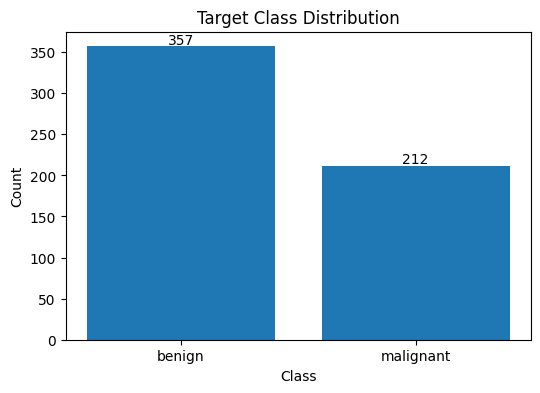

In [13]:
# 클래스별 개수를 막대그래프(bar plot)로 그려 한눈에 비교합니다.
# 그래프 제목과 축 이름은 한글 폰트 문제를 피하기 위해 영어로 작성합니다.
plt.figure(figsize=(6, 4))  # 그래프 크기(가로 6, 세로 4 인치) 지정

# count_by_class 의 인덱스(클래스 이름)를 x축, 값(개수)을 막대 높이로 그립니다.
plt.bar(count_by_class.index, count_by_class.values)

plt.title("Target Class Distribution")  # 제목 (영어)
plt.xlabel("Class")                     # x축 이름
plt.ylabel("Count")                     # y축 이름

# 막대 위에 개수를 숫자로 표시해, 정확한 값을 바로 읽을 수 있게 합니다.
for i, value in enumerate(count_by_class.values):
    plt.text(i, value + 3, str(value), ha="center")

plt.show()

### 기본 통계량 확인

노트북에서는 feature 컬럼에 대해서만 기본 통계를 확인합니다. `.describe()`는 숫자 컬럼의
기본 통계량을 계산합니다. `.T`는 행과 열을 뒤집는 전치(transpose)입니다. feature가 30개이기
때문에 `.T`를 붙이면 각 feature를 위에서 아래로 읽기 편합니다.

| 항목 | 의미 |
|---|---|
| count | 데이터 개수 (결측치 없으면 569) |
| mean | 평균값 |
| std | 표준편차 (값이 평균에서 얼마나 퍼져 있는지) |
| min | 최솟값 |
| 25% | 1사분위수 (하위 25% 지점) |
| 50% | 중앙값 |
| 75% | 3사분위수 (하위 75% 지점) |
| max | 최댓값 |

In [14]:
# feature 컬럼들에 대해서만 기본 통계를 봅니다.
# .describe() 가 통계를 계산하고, .T 로 보기 좋게 행/열을 뒤집습니다.
# (행=feature, 열=통계값 형태가 되어 30개 feature를 위에서 아래로 읽기 편해집니다.)
df[feature_names].describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 악성/양성별 평균 비교

노트북에서는 target_name별 feature 평균을 비교합니다. 이 분석은 어떤 feature에서 악성과
양성의 차이가 큰지 파악하는 데 도움이 됩니다.

| 컬럼 | 의미 |
|---|---|
| malignant | 악성 샘플의 feature 평균 |
| benign | 양성 샘플의 feature 평균 |
| difference | malignant 평균 - benign 평균 |
| abs_difference | 평균 차이의 절댓값 (크기만 비교) |

> 핵심 정리: 평균 차이가 큰 feature는 두 클래스를 구분하는 데 도움이 될 가능성이 있습니다.
> 이 결과는 나중에 feature importance와 비교해 볼 수 있습니다.

In [15]:
# target_name(benign/malignant) 으로 그룹을 나눈 뒤,
# 각 feature의 평균을 계산합니다. .T 로 보기 좋게 뒤집습니다.
# 결과 형태: 행=feature, 열=benign 평균, malignant 평균
mean_compare = df.groupby("target_name")[feature_names].mean().T

# 악성 평균에서 양성 평균을 뺀 '차이(difference)' 컬럼을 추가합니다.
# 값이 양수로 크면 → 악성에서 평균이 더 큰 feature 라는 의미입니다.
mean_compare["difference"] = (
    mean_compare["malignant"] - mean_compare["benign"]
)

# 차이의 절댓값(abs_difference) 컬럼도 추가합니다.
# 부호(+/-)와 상관없이 '차이의 크기' 만으로 정렬하기 위함입니다.
mean_compare["abs_difference"] = mean_compare["difference"].abs()

# 차이의 크기가 큰 순서대로 정렬해서 상위 15개를 봅니다.
# (위에 오는 feature일수록 두 그룹의 평균이 많이 다르다는 뜻)
mean_compare.sort_values("abs_difference", ascending=False).head(15)

target_name,benign,malignant,difference,abs_difference
worst area,558.899440,1422.286321,863.386881,863.386881
mean area,462.790196,978.376415,515.586219,515.586219
worst perimeter,87.005938,141.370330,54.364392,54.364392
area error,21.135148,72.672406,51.537257,51.537257
mean perimeter,78.075406,115.365377,37.289971,37.289971
worst radius,13.379801,21.134811,7.755010,7.755010
worst texture,23.515070,29.318208,5.803138,5.803138
mean radius,12.146524,17.462830,5.316306,5.316306
mean texture,17.914762,21.604906,3.690144,3.690144
perimeter error,2.000321,4.323929,2.323608,2.323608


### selected_features 선택 및 히스토그램 비교

노트북에서 사용하는 대표 feature 목록은 다음과 같습니다. 30개 feature 중 시각화와 분석에
집중할 8개를 선택합니다.

- **크기 관련 feature**: mean radius, mean perimeter, mean area, worst radius, worst perimeter, worst area
- **모양 관련 feature**: mean concave points, worst concave points (오목한 지점의 불규칙성을 나타냄)

selected_features가 실제 데이터에 존재하는지 확인한 뒤, 양성/악성 데이터를 따로 분리해
히스토그램을 겹쳐 그립니다.

- 🟢 초록색: Benign (양성)
- 🔴 빨간색: Malignant (악성)

히스토그램을 볼 때는 다음 세 가지를 중심으로 해석합니다.
1. 양성과 악성의 분포 위치가 서로 다른가?
2. 두 분포가 많이 겹치는가, 아니면 어느 정도 분리되는가?
3. 값이 커질수록 특정 클래스의 비율이 높아지는 경향이 있는가?

In [16]:
# 분포 비교(히스토그램/박스플롯)에 사용할 대표 feature 목록입니다.
# 크기 관련(radius/perimeter/area) + 모양 관련(concave points) 을
# mean(평균) 계열과 worst(가장 심한 부분) 계열로 나누어 골랐습니다.
selected_features = [
    "mean radius",
    "mean perimeter",
    "mean area",
    "mean concave points",
    "worst radius",
    "worst perimeter",
    "worst area",
    "worst concave points"
]

# 선택한 feature 들이 실제로 데이터에 존재하는지 확인합니다.
# (오타가 있으면 그래프 단계에서 오류가 나므로 미리 점검합니다.)
print("선택한 feature 개수:", len(selected_features))
print("모두 데이터에 존재하는가?:", all(f in feature_names for f in selected_features))

선택한 feature 개수: 8
모두 데이터에 존재하는가?: True


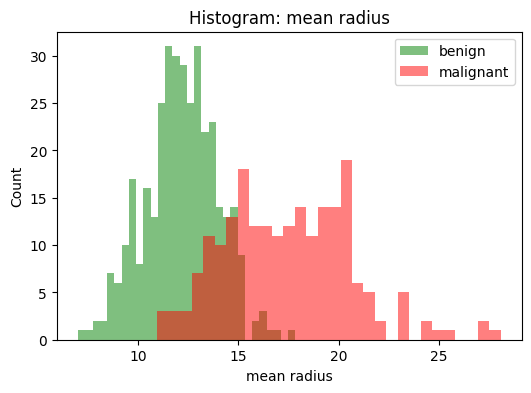

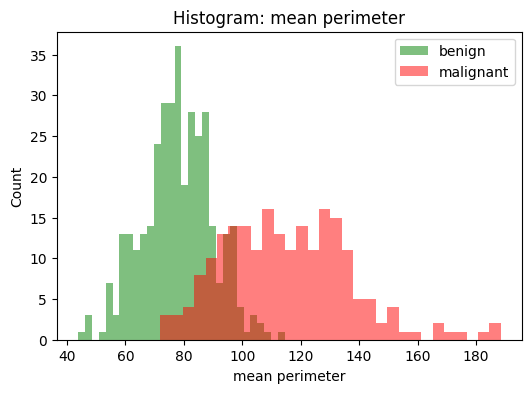

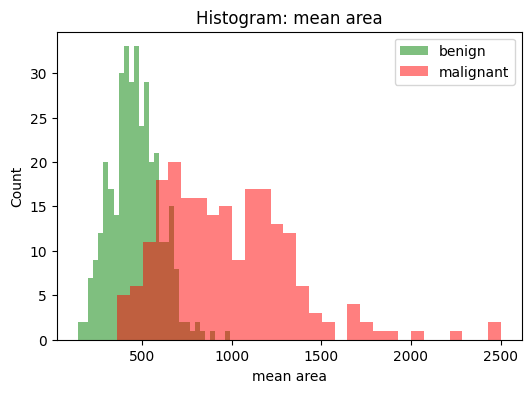

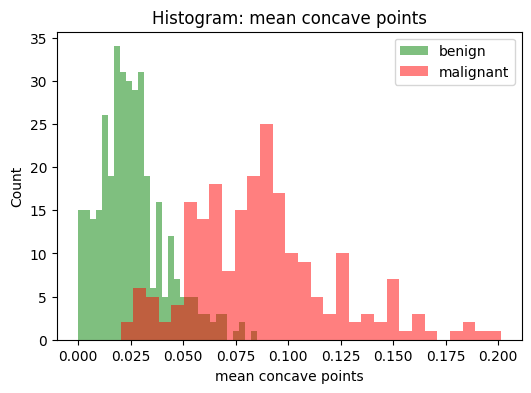

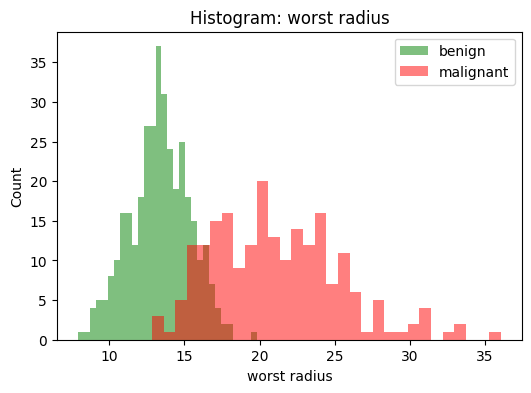

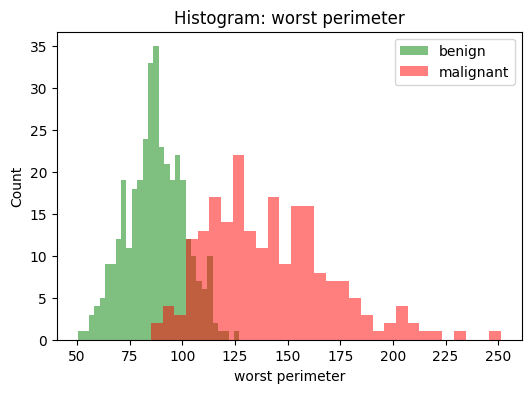

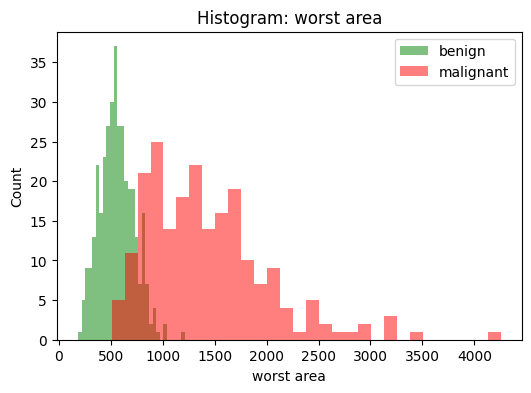

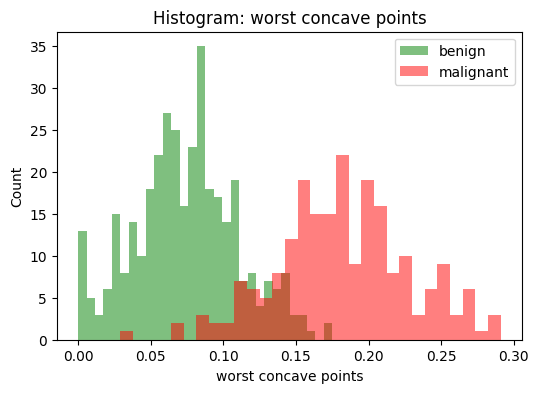

In [17]:
# 그래프에서 양성/악성 데이터를 따로 떼어 두면 반복해서 쓰기 편합니다.
# 조건(df["target_name"] == "benign")이 True 인 행만 골라낸 것입니다.
benign_df = df[df["target_name"] == "benign"]
malignant_df = df[df["target_name"] == "malignant"]

# 선택한 feature 들을 하나씩 돌면서(for 반복문) 히스토그램을 그립니다.
for feature in selected_features:
    # feature 하나당 새로운 그래프(figure)를 만듭니다.
    plt.figure(figsize=(6, 4))

    # 양성 데이터의 분포를 그립니다.
    # bins=30 : 막대를 30개 구간으로 나눔
    # alpha=0.5 : 투명도(0~1). 두 분포가 겹쳐 보이도록 반투명하게 설정합니다.
    plt.hist(benign_df[feature], bins=30, alpha=0.5, label="benign", color="green")

    # 악성 데이터의 분포를 같은 그래프 위에 겹쳐 그립니다.
    plt.hist(malignant_df[feature], bins=30, alpha=0.5, label="malignant", color="red")

    # 제목과 축 이름은 영어로 작성합니다. (한글 폰트 깨짐 방지)
    plt.title("Histogram: " + feature)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()  # benign/malignant 구분 범례 표시

    plt.show()

### 박스플롯 비교

박스플롯은 데이터의 분포를 요약해서 보여주는 그래프입니다. 히스토그램이 전체 분포 모양을
보여준다면, 박스플롯은 중앙값·사분위수·이상치를 한눈에 확인할 수 있습니다.

| 확인 항목 | 의미 |
|---|---|
| 중앙값 (가운데 선) | 두 클래스의 중앙값이 다른가? |
| 박스 위치 | 악성의 박스가 양성보다 위쪽에 있는가? |
| 박스 크기 | 값의 범위가 얼마나 겹치는가? |
| 이상치 (점) | 박스 밖에 튀어나온 값이 있는가? |

> 이상치가 있다고 해서 무조건 잘못된 데이터는 아닙니다. 이번 실습에서는 이상치를 삭제하는
> 방법을 다루기보다, 박스플롯에서 이상치가 어떻게 보이는지 확인하는 데 집중합니다.

> 박스플롯 결과 해석: 대부분의 selected_features에서 malignant의 박스가 benign보다 위쪽에
> 위치합니다. 즉, malignant의 중앙값과 전반적인 값이 더 큰 경향이 있습니다. 이는 히스토그램
> 결과와 일치하는 방향입니다.

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


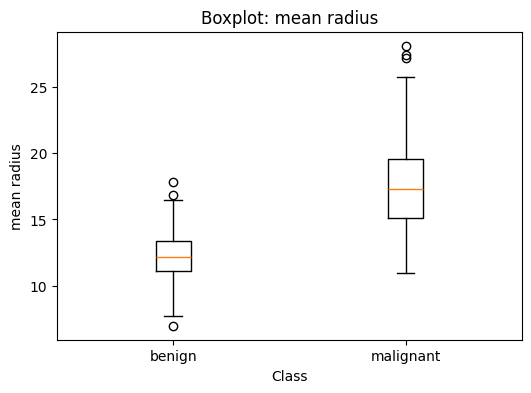

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


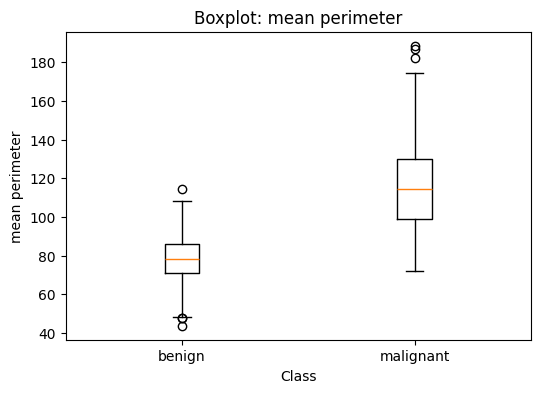

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


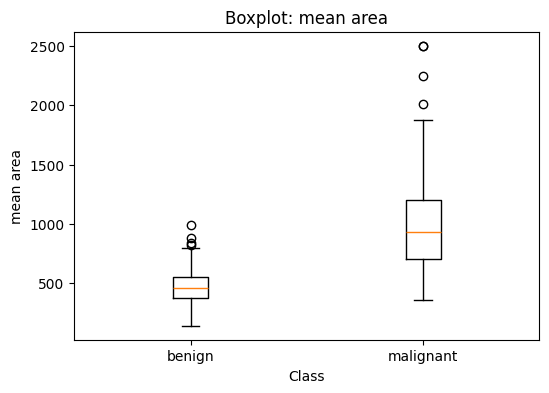

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


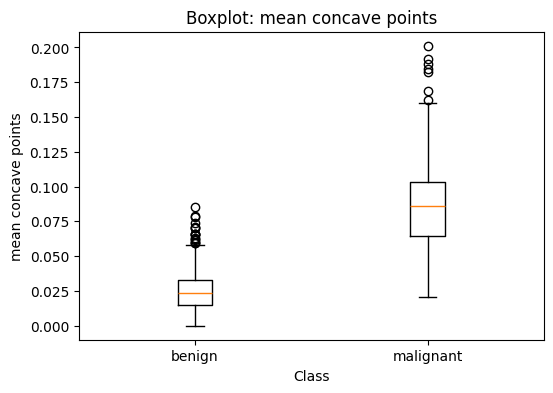

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


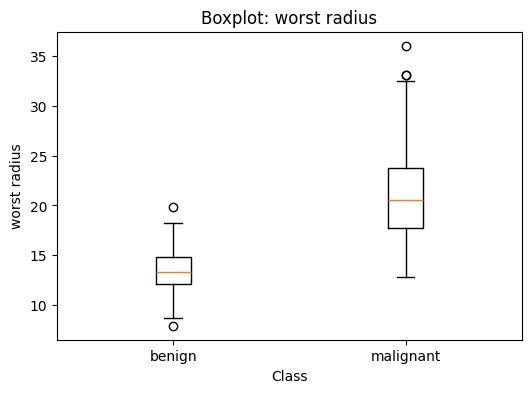

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


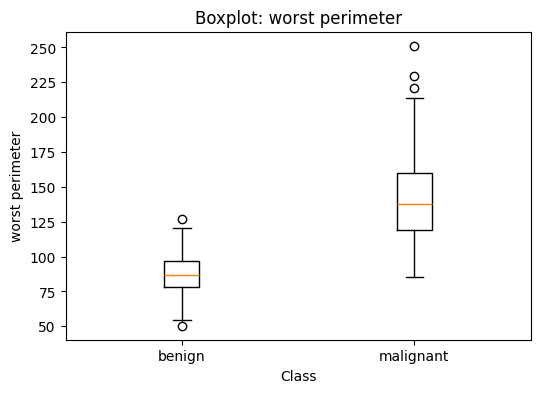

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


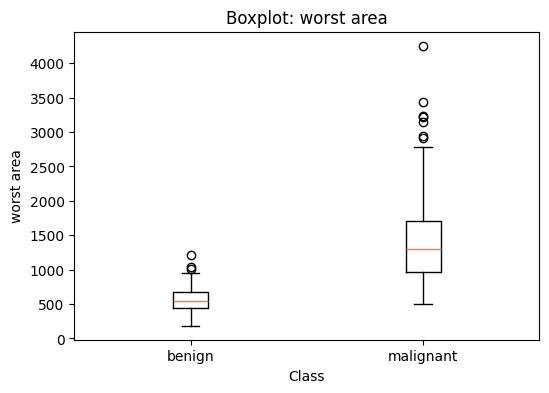

/tmp/ipykernel_686/3563666126.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=["benign", "malignant"])


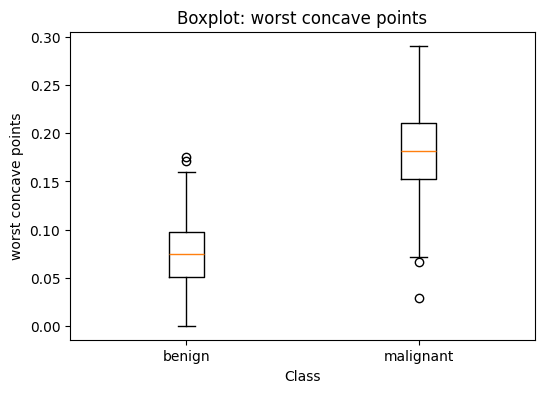

In [18]:
# 선택한 feature 들을 하나씩 돌면서 박스플롯을 그립니다.
for feature in selected_features:
    plt.figure(figsize=(6, 4))

    # 양성과 악성 각각의 feature 값을 리스트로 묶어서 한 그래프에 그립니다.
    # boxplot 에 [양성값, 악성값] 을 넣으면 박스 2개가 나란히 그려집니다.
    data_for_box = [benign_df[feature], malignant_df[feature]]

    # labels 로 각 박스 아래에 표시할 이름을 지정합니다.
    plt.boxplot(data_for_box, labels=["benign", "malignant"])

    plt.title("Boxplot: " + feature)
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.show()

### target과 feature의 상관관계

상관관계는 두 값이 함께 움직이는 정도를 나타냅니다. 상관계수는 -1에서 1 사이의 값을 가집니다.

| 값 | 의미 |
|---|---|
| 1에 가까움 | 한쪽이 커질 때 다른 쪽도 커지는 경향 |
| -1에 가까움 | 한쪽이 커질 때 다른 쪽은 작아지는 경향 |
| 0에 가까움 | 선형 관계가 약함 |

> 수업용 target 기준 해석: 수업용 target에서 0 = benign, 1 = malignant입니다. 따라서 target과
> 양의 상관이 큰 feature는 값이 클수록 malignant일 가능성이 커지는 경향을 의미합니다.
>
> 주의: 상관관계가 높다고 해서 인과관계라고 말할 수는 없습니다. 상관관계는 함께 움직이는
> 정도를 보여줄 뿐입니다.

In [19]:
# target과 각 feature 사이의 상관계수를 계산하고, target 자기 자신은 제외합니다.
target_corr = df[feature_names + ["target"]].corr()["target"].drop("target")

# 상관계수가 큰 순서로 정렬해서 상위 15개를 확인합니다.
target_corr.sort_values(ascending=False).head(15)

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
mean compactness        0.596534
worst compactness       0.590998
radius error            0.567134
perimeter error         0.556141
area error              0.548236
Name: target, dtype: float64

### target 상관관계 막대그래프

노트북에서는 상위 15개 feature를 가로 막대그래프로 그립니다. 가로 막대그래프는 feature 이름이 길 때 읽기 편합니다.

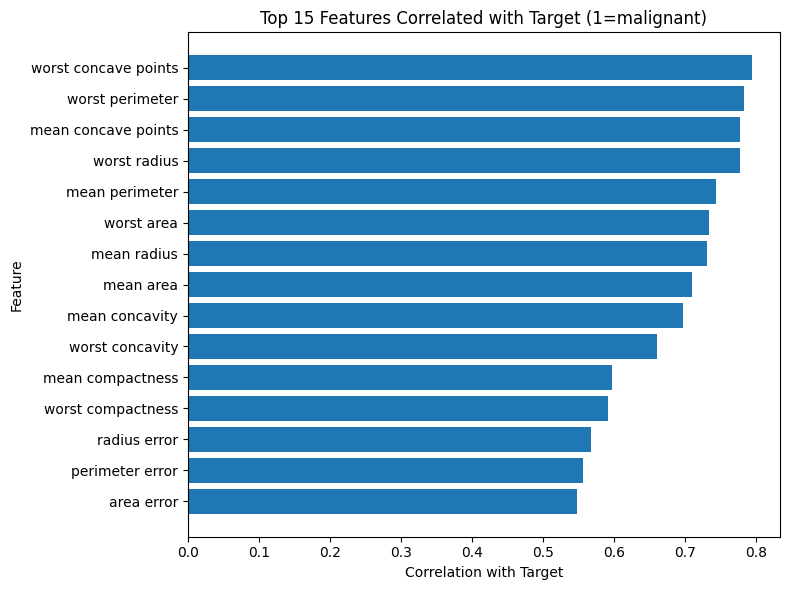

In [20]:
# 상관이 큰 상위 15개 feature 를 가로 막대그래프(barh)로 그립니다.
# 가로 막대는 feature 이름이 길어도 읽기 편합니다.
top15_corr = target_corr.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))

# barh 는 가로 막대그래프(horizontal bar)입니다.
plt.barh(top15_corr.index, top15_corr.values)

# 기본 barh 는 아래에서 위로 그려지므로,
# 가장 큰 값이 맨 위로 오도록 y축을 뒤집습니다.
plt.gca().invert_yaxis()

plt.title("Top 15 Features Correlated with Target (1=malignant)")
plt.xlabel("Correlation with Target")
plt.ylabel("Feature")
plt.tight_layout()  # 라벨이 잘리지 않도록 여백 자동 조정
plt.show()

### feature 간 상관관계 heatmap

feature끼리 서로 비슷한 정보를 담고 있을 수 있습니다. 예를 들어 mean radius, mean perimeter,
mean area는 모두 세포핵의 크기와 관련된 feature이므로 서로 강하게 관련될 수 있습니다.

| 색 | 의미 |
|---|---|
| 빨간색 (진함) | 강한 양의 상관관계 |
| 파란색 (진함) | 강한 음의 상관관계 |
| 색이 연함 | 상관관계가 약함 |

> heatmap 해석: radius, perimeter, area 계열처럼 서로 비슷한 정보를 담은 feature가 많다는
> 점을 확인할 수 있습니다. 상관관계가 높은 feature가 있다고 해서 반드시 나쁜 것은 아닙니다.
> 다만 모델 해석 시 비슷한 정보를 가진 feature가 여러 개 있을 수 있다는 점을 기억해야 합니다.

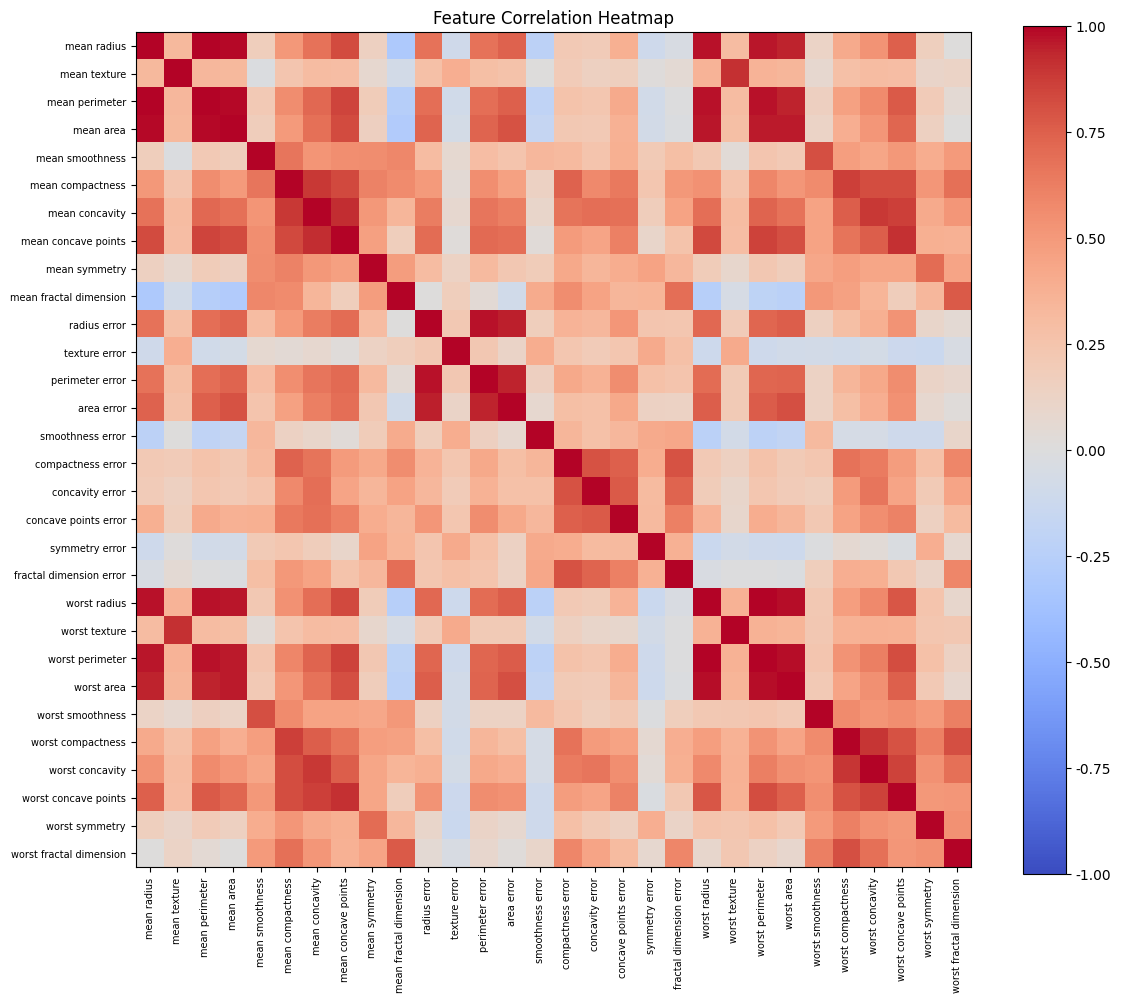

In [21]:
# 30개 feature 간 상관관계 표(행렬)를 계산합니다.
corr_matrix = df[feature_names].corr()

# imshow 로 상관관계 표를 색으로 표현합니다. (heatmap)
plt.figure(figsize=(12, 10))

# cmap="coolwarm" : 음의 상관은 파랑, 양의 상관은 빨강 계열로 표시
# vmin/vmax 로 색의 범위를 -1 ~ 1 로 고정해, 색과 값의 의미를 일정하게 맞춥니다.
image = plt.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

# 색이 어떤 값을 의미하는지 알려주는 색상 막대(colorbar)를 추가합니다.
plt.colorbar(image)

# x축, y축에 feature 이름을 표시합니다. (글자가 많아 x축은 90도 회전시켜 표시)
plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=7)
plt.yticks(range(len(feature_names)), feature_names, fontsize=7)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Section 4. 모델 학습

데이터 분할 후 XGBoost 모델을 학습합니다.

### train/test split

모델을 학습한 뒤 성능을 평가하려면, 학습에 사용하지 않은 데이터로 평가해야 합니다. 이를 위해
전체 데이터를 학습용(train)과 평가용(test)으로 나눕니다.

| 파라미터 | 값 | 의미 |
|---|---|---|
| X | - | 입력 feature 전체 |
| y | - | 변환된 target (0=양성, 1=악성) |
| test_size | 0.2 | 전체 데이터의 20%를 평가용으로 사용 |
| random_state | 42 | 같은 결과가 나오도록 난수 고정 |
| stratify | y | 양성/악성 비율을 train/test에 비슷하게 유지 |

> stratify=y를 사용하는 이유: 분류 문제에서는 학습용과 평가용 데이터의 클래스 비율을 비슷하게
> 유지하는 것이 중요합니다. stratify=y를 사용하지 않으면 우연히 한쪽 클래스가 평가용 데이터에
> 너무 많거나 적게 들어갈 수 있습니다.

In [22]:
# 데이터를 학습용(train)과 평가용(test)으로 나눕니다.
# X = 입력 feature, y = 정답(0=양성, 1=악성)
X_train, X_test, y_train, y_test = train_test_split(
    X,                    # 입력 feature 전체
    y,                    # 정답 전체
    test_size=0.2,        # 20% 를 평가용으로 사용 (나머지 80% 는 학습용)
    random_state=42,      # 매번 같은 방식으로 나누도록 고정 (재현 가능)
    stratify=y            # 양성/악성 비율을 train/test 에 비슷하게 유지
)

# 나눠진 결과의 크기를 확인합니다. (행 수가 8:2 정도로 나뉘었는지 확인)
print("학습용 입력 크기:", X_train.shape)
print("평가용 입력 크기:", X_test.shape)

# stratify 가 잘 동작했는지, train/test 의 악성 비율을 확인합니다.
# y.mean() 은 'target 값(0/1)의 평균' = '1(악성)의 비율' 과 같습니다.
# 두 값이 비슷하면 비율이 잘 유지된 것입니다.
print("\n학습용 악성 비율:", round(y_train.mean(), 3))
print("평가용 악성 비율:", round(y_test.mean(), 3))

학습용 입력 크기: (455, 30)
평가용 입력 크기: (114, 30)

학습용 악성 비율: 0.374
평가용 악성 비율: 0.368


### XGBoost 모델 만들기

XGBoost는 여러 개의 작은 결정 트리를 순차적으로 학습하는 모델입니다. 이전 트리가 잘 맞히지
못한 부분을 다음 트리가 보완하는 방식으로 성능을 높입니다. 이번 데이터는 이진 분류 문제이므로
XGBClassifier를 사용합니다.

| 파라미터 | 값 | 의미 |
|---|---|---|
| n_estimators | 100 | 트리 100개 생성 |
| max_depth | 3 | 각 트리의 최대 깊이를 3으로 제한 |
| learning_rate | 0.1 | 한 번에 조금씩 학습 (너무 크면 과적합 위험) |
| random_state | 42 | 결과 재현을 위한 난수 고정 |
| eval_metric | logloss | 예측 확률의 오차를 평가 기준으로 사용 |

> 초보자 팁: 처음에는 파라미터 하나하나를 완벽히 이해하려 하기보다, 기본 파라미터로 모델 학습
> 흐름을 먼저 이해하는 것이 중요합니다.

In [23]:
# XGBoost 분류 모델을 만듭니다. 각 설정값의 의미는 주석을 참고하세요.
model = XGBClassifier(
    n_estimators=100,     # 트리를 100개 만듭니다. (많을수록 표현력↑, 너무 많으면 과적합 위험)
    max_depth=3,           # 각 트리의 최대 깊이를 3으로 제한합니다. (과하게 복잡해지는 것 방지)
    learning_rate=0.1,     # 한 번에 조금씩(0.1) 학습해 안정적으로 성능을 올립니다.
    random_state=42,       # 매번 같은 결과가 나오도록 난수를 고정합니다. (재현 가능)
    eval_metric="logloss"  # 학습 중 성능을 측정할 기준으로 logloss(예측 확률의 오차)를 사용합니다.
)

print("모델 생성 완료:", type(model).__name__)

모델 생성 완료: XGBClassifier


### XGBoost 모델 학습

`fit()`은 입력 데이터와 정답 데이터의 관계를 학습하라는 의미입니다.

| 요소 | 의미 |
|---|---|
| X_train | 문제 (30개 feature로 이루어진 학습용 입력 데이터) |
| y_train | 정답 (0=양성, 1=악성으로 변환된 수업용 target) |
| fit() | 문제와 정답의 관계를 학습 (XGBoost가 여러 feature를 기준으로 데이터를 나누는 규칙을 학습) |

> XGBoost는 여러 feature를 기준으로 데이터를 나누는 규칙을 학습합니다. 학습이 완료되면 새로운
> 데이터가 들어왔을 때 어떤 클래스인지 예측할 수 있게 됩니다.

In [24]:
# 학습용 데이터로 모델을 학습시킵니다.
# fit() 은 '입력(X_train)을 보고 정답(y_train)을 맞추는 규칙을 배워라' 는 의미입니다.
# 이 한 줄이 실행되는 동안 XGBoost 가 트리 100개를 순차적으로 만들며 학습합니다.
model.fit(X_train, y_train)

print("모델 학습 완료")

모델 학습 완료


## Section 5. 모델 평가

Accuracy, ROC-AUC, classification_report, confusion matrix로 성능을 평가합니다.

### 예측과 악성 확률 계산

노트북에서는 평가용 데이터에 대해 예측 클래스와 악성일 확률을 구합니다.

| 결과 | 의미 |
|---|---|
| y_pred | model.predict(X_test)의 결과. 각 샘플에 대해 0 또는 1을 반환 |
| y_pred_proba | predict_proba(X_test)[:, 1]. 각 샘플이 악성(1)일 확률 (0~1 사이 소수값) |

> 수업용 target 기준: predict_proba()[:, 1]의 1은 클래스 1, 즉 malignant(악성)의 확률입니다.
> 이 값은 ROC-AUC 계산에 사용됩니다.

### Accuracy와 ROC-AUC

| 지표 | 사용 값 | 의미 |
|---|---|---|
| Accuracy | y_pred (0 또는 1) | 전체 평가 데이터 중 맞게 예측한 비율 |
| ROC-AUC | y_pred_proba (확률값) | 예측 확률을 기준으로 두 클래스를 구분하는 능력 |

- Accuracy 계산식: (TP + TN) / (TP + TN + FP + FN)
- 주의사항: 클래스 불균형이 심할 때 Accuracy만 보면 오해할 수 있습니다. 예: 악성이 10%인
  데이터에서 모두 양성으로 예측해도 Accuracy 90%.
- ROC-AUC 계산식: ROC 곡선 아래 면적 (0~1). 임계값(threshold)에 관계없이 모델의 전반적인
  분류 능력을 평가하며, 클래스 불균형에도 비교적 강건합니다.

| AUC 값 | 의미 |
|---|---|
| 1.0 | 완벽한 분류 |
| 0.9 이상 | 매우 우수 |
| 0.7~0.9 | 양호 |
| 0.5 | 랜덤 수준 (무의미) |
| 0.5 미만 | 랜덤보다 나쁨 |

In [25]:
# 평가용 입력(X_test)에 대해 모델이 예측한 클래스(0 또는 1)를 구합니다.
y_pred = model.predict(X_test)

# 악성(1)일 확률도 구합니다.
# predict_proba 는 각 샘플에 대해 [양성일 확률, 악성일 확률] 두 값을 돌려주므로,
# [:, 1] 로 두 번째 열(악성일 확률)만 뽑습니다.
# (악성을 1로 두었기 때문에 이렇게 '악성일 확률' 로 바로 해석할 수 있습니다.)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 정확도(accuracy): 전체 평가 데이터 중 맞게 예측한 비율
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy(정확도):", round(accuracy, 4))

# ROC-AUC: 악성/양성을 구분하는 능력 (예측 클래스가 아니라 '확률값'을 사용)
# 1에 가까울수록 두 클래스를 잘 구분한다는 의미입니다.
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", round(roc_auc, 4))

Accuracy(정확도): 0.9649
ROC-AUC: 0.9944


### classification_report

classification_report는 클래스별 precision, recall, f1-score를 보여줍니다. target_names를
지정하면 0/1 대신 글자 라벨로 보여줘서 읽기 쉽습니다.

| 지표 | 의미 |
|---|---|
| precision | 해당 클래스로 예측한 것 중 실제로 맞은 비율 |
| recall | 실제 해당 클래스 중 모델이 찾아낸 비율 |
| f1-score | precision과 recall의 균형 (두 값의 조화 평균) |
| support | 실제 데이터 개수 |

> ⚠️ target_names 순서 주의: target_names의 순서는 반드시 [0번 클래스, 1번 클래스]입니다.
> 수업용 target 기준: 0 = benign, 1 = malignant. 따라서 target_names=["benign", "malignant"]가
> 올바른 순서입니다.

> malignant recall이 특히 중요한 이유: malignant recall은 실제 악성 샘플 중에서 모델이
> 악성이라고 제대로 예측한 비율입니다. 의료 데이터 예제에서는 실제 악성을 양성으로 놓치는 것
> (FN)이 중요한 문제로 해석될 수 있으므로, accuracy만 보지 말고 malignant recall을 함께
> 확인해야 합니다. 단, 이 실습은 실제 의료 진단이 아니라 머신러닝 평가 구조를 이해하기 위한
> 예제입니다.

In [26]:
# classification_report 는 클래스별 precision, recall, f1-score 를 보여줍니다.
# target_names 를 지정하면 0/1 대신 글자 라벨로 보여줘서 읽기 쉽습니다.
# 순서는 [0번 클래스, 1번 클래스] = ["benign", "malignant"] 입니다.
report = classification_report(
    y_test,
    y_pred,
    target_names=["benign", "malignant"]
)

print(report)

              precision    recall  f1-score   support

      benign       0.95      1.00      0.97        72
   malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



### confusion matrix (혼동 행렬)

confusion matrix는 실제값과 예측값을 비교하는 표입니다.

| | 예측: benign (0) | 예측: malignant (1) |
|---|---|---|
| 실제: benign (0) | TN (True Negative) | FP (False Positive) |
| 실제: malignant (1) | FN (False Negative) | TP (True Positive) |

> labels=[0, 1]을 지정하면 행과 열의 순서가 [benign(0), malignant(1)]로 고정됩니다. 이 순서를
> 명시하지 않으면 결과 해석이 헷갈릴 수 있습니다.

> ⚠️ 수업용 target 기준 confusion matrix 구조: [[TN, FP], [FN, TP]]

**FN(False Negative)이 중요한 이유**: FN은 실제로는 malignant인데 모델이 benign으로 예측한
경우입니다. 즉, 악성을 양성으로 놓친 경우입니다. 이 오류는 confusion matrix의 왼쪽 아래 칸에
해당합니다. 따라서 accuracy만 볼 것이 아니라 malignant recall, FN 개수를 함께 확인해야 합니다.
(이 실습은 실제 의료 진단이 아니라 머신러닝 평가 구조를 이해하기 위한 예제입니다.)

In [27]:
# confusion_matrix(혼동 행렬) 를 계산합니다.
# labels=[0, 1] 로 지정해 행/열 순서를 [benign(0), malignant(1)] 로 고정합니다.
# (순서를 고정해야 아래 TN/FP/FN/TP 해석과 정확히 일치합니다.)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  0]
 [ 4 38]]


### Confusion Matrix 계산법 상세

| 지표 | 계산식 | 의미 |
|---|---|---|
| Accuracy (정확도) | (TP + TN) / (TP + TN + FP + FN) | 전체 예측 중 맞힌 비율. 클래스 불균형이 있을 때는 단독으로 신뢰하기 어렵습니다. |
| Precision (정밀도) | TP / (TP + FP) | malignant로 예측한 것 중 실제로 malignant인 비율. FP를 줄이는 것이 중요할 때 사용합니다. |
| Recall (재현율) | TP / (TP + FN) | 실제 malignant 중 모델이 malignant로 맞힌 비율. 의료 데이터처럼 FN을 줄이는 것이 중요할 때 핵심 지표입니다. |
| F1-score | 2 × (Precision × Recall) / (Precision + Recall) | Precision과 Recall의 조화평균. 두 지표의 균형을 하나의 숫자로 나타냅니다. |

confusion matrix를 matplotlib으로 시각화하면 각 칸이 TN/FP/FN/TP 중 무엇을 의미하는지, 그리고
실제 개수가 얼마인지 한눈에 볼 수 있습니다.

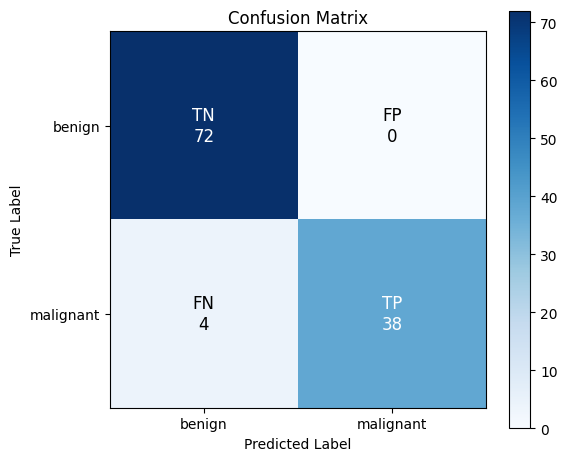

In [28]:
# 각 칸에 붙일 이름표를 우리 구조([[TN, FP],[FN, TP]])에 맞춰 만듭니다.
cell_labels = [["TN", "FP"],
               ["FN", "TP"]]

plt.figure(figsize=(6, 5))

# confusion matrix 숫자를 색으로 표현합니다. (값이 클수록 진한 파랑)
plt.imshow(cm, cmap="Blues")
plt.colorbar()

# x축(예측), y축(실제)에 클래스 이름을 표시합니다.
plt.xticks([0, 1], ["benign", "malignant"])
plt.yticks([0, 1], ["benign", "malignant"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# 각 칸 가운데에 이름표(TN/FP/FN/TP)와 숫자를 함께 적습니다.
for row in range(2):
    for col in range(2):
        text = cell_labels[row][col] + "\n" + str(cm[row, col])
        # 칸 색이 어두우면 글자를 흰색으로, 밝으면 검은색으로 해서 잘 보이게 합니다.
        color = "white" if cm[row, col] > cm.max() / 2 else "black"
        plt.text(col, row, text, ha="center", va="center", color=color, fontsize=12)

plt.tight_layout()
plt.show()

## Section 6. 결과 해석 & 복습

Feature Importance 분석, EDA와 모델 결과 연결

### feature importance 확인

feature importance는 XGBoost가 학습 후 어떤 feature를 분류에 많이 사용했는지 보여주는
값입니다.

In [29]:
# feature 이름과 그 중요도를 짝지어 표(DataFrame)로 만듭니다.
# model.feature_importances_ 는 feature_names 와 같은 순서로 들어 있으므로,
# 이름과 중요도를 그대로 나란히 묶을 수 있습니다.
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

# 중요도가 높은 순서대로 정렬합니다. (위에 올수록 모델이 많이 사용한 feature)
importance_df = importance_df.sort_values("importance", ascending=False)

# 상위 15개를 확인합니다.
importance_df.head(15)

,feature,importance
22,worst perimeter,0.278365
20,worst radius,0.251420
7,mean concave points,0.129637
27,worst concave points,0.080885
6,mean concavity,0.026811
26,worst concavity,0.025531
3,mean area,0.020768
1,mean texture,0.019833
21,worst texture,0.017856
16,concavity error,0.016952


### feature importance 시각화

상위 15개 feature importance를 가로 막대그래프로 그립니다.

**feature importance 해석 시 주의사항**
- 중요도가 높다는 것은 모델이 해당 feature를 예측에 많이 활용했다는 뜻입니다.
- 중요도가 높다고 해서 해당 feature가 의학적 원인이라는 뜻은 아닙니다.
- 비슷한 정보를 가진 feature끼리 importance가 나뉠 수 있습니다. 예를 들어 radius, perimeter,
  area는 서로 강하게 관련되어 있어 importance가 분산될 수 있습니다.

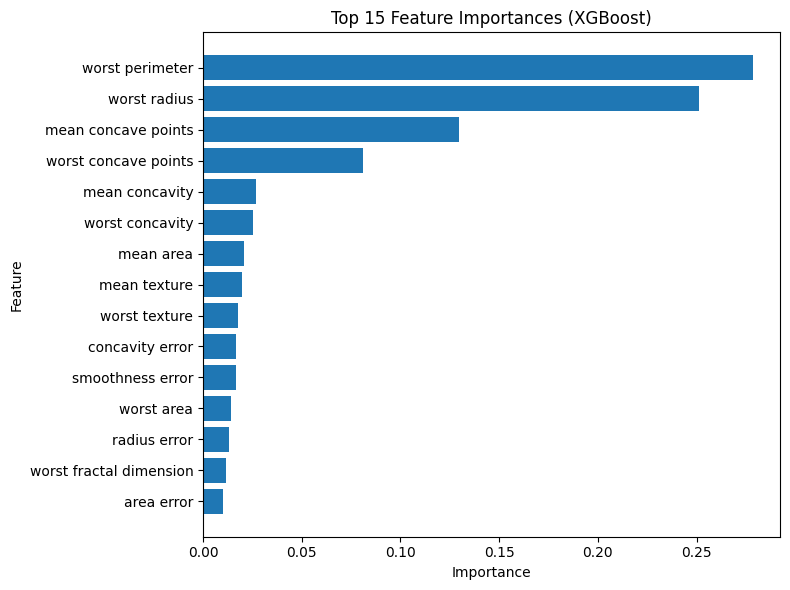

In [30]:
# 중요도 상위 15개 feature 를 가로 막대그래프로 그립니다.
top15_importance = importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top15_importance["feature"], top15_importance["importance"])

# 가장 중요한 feature 가 맨 위로 오도록 y축을 뒤집습니다.
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### EDA와 feature importance 연결

이번 노트북의 핵심 메시지는 EDA와 모델 결과를 연결하는 것입니다.

> EDA는 모델 학습 전 사람이 찾은 힌트이고, feature importance는 모델 학습 후 모델이 사용한
> 힌트입니다.

1. **EDA 단계**: 히스토그램, 박스플롯, 상관관계 분석을 통해 악성/양성 분포 차이가 큰 feature를
   사람이 먼저 확인합니다.
2. **모델 학습**: XGBoost가 30개 feature를 기준으로 데이터를 나누는 규칙을 학습합니다.
3. **feature importance**: EDA에서 분포 차이가 컸던 feature가 모델에서도 높은 importance를
   받을 수 있습니다. 이 경우 EDA와 모델 해석이 자연스럽게 연결됩니다.

> 주의할 점: 비슷한 정보를 가진 feature끼리 importance가 나뉠 수 있습니다. 예를 들어 radius,
> perimeter, area는 서로 강하게 관련되어 있을 수 있으므로, 하나의 feature에 importance가
> 집중되지 않고 여러 feature에 분산될 수 있습니다.

---

## 최종 정리

이번 노트북에서 수행한 전체 작업을 순서대로 정리합니다.

1. **환경 준비 및 EDA 이해**: 실습 환경을 준비하고, EDA가 왜 필요한지 이해했습니다.
2. **데이터 준비**: Breast Cancer 데이터셋을 불러오고, feature_names 변수를 정의하고, 입력
   데이터 X를 DataFrame으로 만들었습니다.
3. **target 변환**: sklearn 원본 target을 수업용 target으로 변환하고, target_name을 만들고,
   분석용 DataFrame df를 생성했습니다.
4. **EDA 수행**: 데이터 크기·타입·결측치 확인, target 분포, 기본 통계, 클래스별 평균 비교,
   히스토그램, 박스플롯, 상관관계, heatmap을 분석했습니다.
5. **모델 학습 및 평가**: XGBoost 모델을 학습하고, Accuracy·ROC-AUC·classification_report·
   confusion matrix·feature importance를 확인하고, EDA 결과와 모델 결과를 연결했습니다.

### 수강생 복습 정리

| 핵심 항목 | 내용 |
|---|---|
| EDA | 모델 학습 전 데이터를 이해하는 과정 |
| 시각화 도구 | 노트북은 seaborn이 아니라 matplotlib 사용 |
| 원본 target | 0 = malignant, 1 = benign |
| 수업용 target | 0 = benign, 1 = malignant |
| 원본 보관 | y_original Series로 보관 |
| 수업용 target | y로 생성 (1 - y_original) |
| df 구조 | 30개 feature + target + target_name = 32개 컬럼 |
| selected_features | 8개 feature 사용 (크기 관련 6개 + concave points 2개) |
| XGBoost 파라미터 | n_estimators=100, max_depth=3, learning_rate=0.1 |
| ROC-AUC 입력값 | 악성 확률 predict_proba()[:, 1] 사용 |
| confusion matrix | labels=[0, 1]로 순서 고정 |

> ⚠️ target 기준 최종 확인:
> - sklearn 원본: 0 = malignant, 1 = benign
> - 수업용 (노트북 기준): 0 = benign, 1 = malignant
>
> 이 기준을 혼동하면 predict_proba()[:, 1], malignant recall, FN 해석이 모두 틀려집니다.

### 주요 용어 정리

| 용어 | 의미 |
|---|---|
| EDA | 탐색적 데이터 분석 (Exploratory Data Analysis) |
| feature | 모델이 예측할 때 사용하는 입력값 |
| target | 모델이 맞혀야 하는 정답 |
| benign | 양성, 악성이 아닌 범주 (수업용 target: 0) |
| malignant | 악성 범주 (수업용 target: 1) |
| classification | 분류 |
| binary classification | 이진 분류 (두 클래스 중 하나로 분류) |
| histogram | 값의 분포를 보는 그래프 |
| boxplot | 중앙값, 사분위수, 이상치를 보는 그래프 |
| correlation | 두 변수가 함께 움직이는 정도 |
| heatmap | 값을 색으로 표현한 그래프 |
| train/test split | 학습용과 평가용 데이터를 나누는 과정 |
| XGBoost | 여러 결정 트리를 순차적으로 학습하는 모델 |
| Accuracy | 전체 중 맞힌 비율 |
| ROC-AUC | 예측 확률을 기준으로 두 클래스를 구분하는 능력 |
| classification_report | 분류 모델 평가 지표 표 |
| confusion matrix | 실제값과 예측값을 비교하는 표 |
| feature importance | 모델이 중요하게 사용한 feature 정보 |

### 복습 완료 체크리스트

아래 항목을 모두 설명할 수 있으면 이번 실습을 완료한 것입니다.

- [ ] EDA가 왜 필요한지 설명할 수 있다
- [ ] sklearn 원본 target과 수업용 target의 차이를 안다
- [ ] y_original, y, target_name의 역할을 구분할 수 있다
- [ ] confusion matrix의 TN, FP, FN, TP를 해석할 수 있다
- [ ] malignant recall과 FN의 의미를 설명할 수 있다
- [ ] feature importance 해석 시 주의사항을 안다
